## KELT-20b Evolution


### Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

pi = np.pi

# Stellar parameters
m_s = 1 # solar mass
r_s = 0.00465 # AU 
Q_s = 10**6 # Tidal dissipation parameter
k2_s = 0.03 # Love number

# Planetary parameters
m_p = 0.000954588 # solar masses (1 jupiter mass)
r_p = 0.000477895 # AU (1 jupiter radius)
Q_p = 10**4 
k2_p = 0.3 

G = 4*pi**2

# Orbital parameters
e0 = 0.8
a0 = 0.25 # AU

# Modified tidal dissipation parameter
Q_prime_s = 3 * Q_s / (2 * k2_s)
Q_prime_p = 3 * Q_p / (2 * k2_p)

# Time lag parameter
n = np.sqrt(G*(m_s + m_p)/a0**3)
dt_s = 1/(2*Q_s*n)
dt_p = 1/(2*Q_p*n)


### Jackson Equations

Text(0.5, 1.0, 'Jackson & Barnes Tidal Evolution')

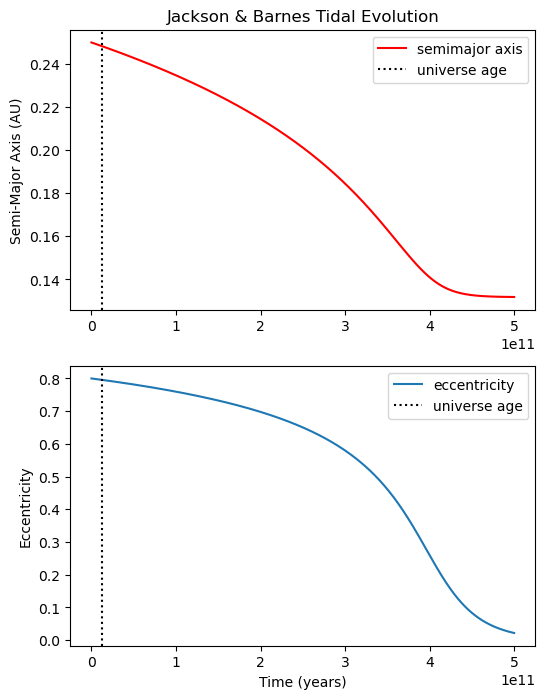

In [2]:
# Time
tmax = 5e11
Nout = 1000
jackson_times = np.linspace(0, tmax, Nout)

def jackson_barnes_model(params, t, mstar, rstar, qstar_prime, mplanet, rplanet, qplanet_prime):
    a, e = params

    da_dt = -a * (63.0/2.0 * np.sqrt(G * mstar**3) * (rplanet**5) / (qplanet_prime * mplanet) * e**2 
                  + (9.0/2.0) * np.sqrt(G / mstar) * (rstar**5 * mplanet)/ qstar_prime * (1.0 + 57.0/4.0 * e**2)) * a**(-13/2)

    de_dt = -e * (63.0/4.0 * np.sqrt(G * mstar**3) * (rplanet**5) / (qplanet_prime * mplanet) + 225.0/16.0 * np.sqrt(G / mstar) * (rstar**5 * mplanet)/ qstar_prime) * a**(-13/2)

    return [da_dt, de_dt]

initial_cond = [a0, e0] # 0.25, 0.8

jackson_barnes_solution = odeint(jackson_barnes_model, initial_cond, jackson_times, 
                           args = (m_s, r_s, Q_prime_s, 
                                  m_p, r_p, Q_prime_p))


# Plotting
a_sol = jackson_barnes_solution[:, 0]
e_sol = jackson_barnes_solution[:, 1]

fig, ax = plt.subplots(2, 1, figsize = (6,8))
ax[0].plot(jackson_times, a_sol, color = "r", label = "semimajor axis")
ax[0].set_ylabel("Semi-Major Axis (AU)")
ax[0].axvline(x = 1.3e10, color = "k", linestyle = "dotted", label = "universe age")
ax[0].legend()

ax[1].plot(jackson_times, e_sol, label = "eccentricity")
ax[1].set_ylabel("Eccentricity")
ax[1].set_xlabel("Time (years)")
ax[1].axvline(x = 1.3e10, color = "k", linestyle = "dotted", label = "universe age")
ax[1].legend()

ax[0].set_title("Jackson & Barnes Tidal Evolution")

### Leconte Equations

Text(0.5, 1.0, 'Leconte Tidal Evolution')

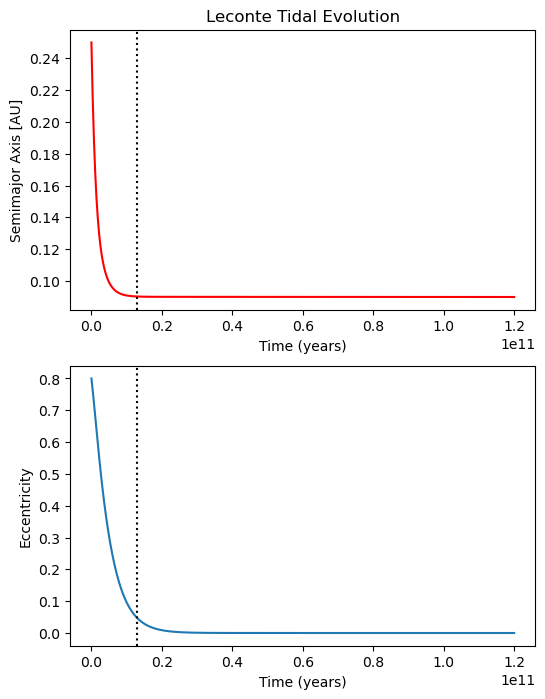

In [3]:
# Time
tmax = 2*np.pi*1.2e11
Nout = 1000
times = np.linspace(0, tmax, Nout)

def leconte_analytic(params, t, mstar, rstar, k2_star, dt_star, C_s, mp, rp, k2_p, dt_p, C_p):
    '''
    Leconte 2010 Eq (2, 6, 10)
    Assumes REBOUND units (G=1)
    '''
    
    a, e, omega_p, omega_s, ep_p, ep_s = params
    n = np.sqrt((mstar + mp) / a**3)
    
    n_e = (1 + (15 / 2) * e**2 + (45 / 8) * e**4 + (5 / 16) * e**6) / (1 - e**2)**6
    n_a_e = (1 + (31 / 2) * e**2 + (255 / 8) * e**4 + (185 / 16) * e**6 + (25 / 64) * e**8) / (1 -  e**2)**(15 / 2)
    n_e_e = (1 + (15 / 4) * e**2 + (15 / 8) * e**4 + (5 / 64) * e**6) / (1 - e**2)**(13 / 2)
    omega_e_e = (1 + (3 / 2) * e**2 + (1 / 8) * e**4) / (1 - e**2)**5
    omega_e = (1 + 3 * e**2 + (3 / 8) * e**4) / (1 - e**2)**(9 / 2)
    
    Kp = 3 * k2_p * dt_p * (mp**2 / rp) * (mstar / mp)**2 * (rp / a)**6 * n**2
    Kstar = 3 * k2_star * dt_star * (mstar**2 / rstar) * (mp / mstar)**2 * (rstar / a)**6 * n**2
    
    eta_p = (mp + mstar) / (mp * mstar) * (C_p * omega_p) / (a**2 * n * np.sqrt(1 - e**2))
    eta_s = (mp + mstar) / (mp * mstar) * (C_s * omega_s) / (a**2 * n * np.sqrt(1 - e**2))
    
    da_dt = (4 * a**2 / (mstar * mp)) * (Kp * (n_e * np.cos(ep_p) * omega_p / n - n_a_e)
                                       + Kstar * (n_e * np.cos(ep_s) * omega_s / n - n_a_e))
    
    de_dt = (11 * a * e / (mstar * mp)) * (Kp * (omega_e_e * np.cos(ep_p) * omega_p / n - (18 / 11) * n_e_e)
                                         + Kstar * (omega_e_e * np.cos(ep_s) * omega_s / n - (18 / 11) * n_e_e))
    
    domega_p_dt = -(Kp / (n * C_p)) * ((1 + np.cos(ep_p)**2) * omega_e * omega_p / n - 2 * np.cos(ep_p) * n_e)
    domega_s_dt = -(Kstar / (n * C_s)) * ((1 + np.cos(ep_s)**2) * omega_e * omega_s / n - 2 * np.cos(ep_s) * n_e)
    
    dep_p_dt = np.sin(ep_p) * ((Kp / (n * omega_p * C_p)) * 
                               ((np.cos(ep_p) - eta_p) * omega_e * omega_p / n - 2 * n_e))
    dep_s_dt = np.sin(ep_s) * ((Kstar / (n * omega_s * C_s)) * 
                               ((np.cos(ep_s) - eta_s) * omega_e * omega_s / n - 2 * n_e))
    
    return [da_dt, de_dt, domega_p_dt, domega_s_dt, dep_p_dt, dep_s_dt]

initial_condition = [a0, e0, 0.01, 0.01, np.radians(0.), np.radians(0.)] # a0, e0, omega_p, omega_s, ep_p, ep_s
analytic_solution = odeint(leconte_analytic, initial_condition, times,
                              args=(m_s, r_s, 0.03, dt_s, 0.07 * m_s * r_s**2,
                                    m_p, r_p, 0.3, dt_p, 0.25 * m_p * r_p**2))


planet_lec_a = analytic_solution[:,0]
planet_lec_e = analytic_solution[:,1]
#planet_lec_n = np.sqrt((m_s + m_p) / (planet_lec_a**3))
#planet_lec_spin = analytic_solution[:,2]
#planet_lec_obliquity = np.degrees(analytic_solution[:,4])

# Plotting
fig, ax = plt.subplots(2,1,figsize=(6, 8))
ax = ax.ravel()

times_rescaled = times / (2 * np.pi) # this converts from REBOUND time units to kyr

#ax[0].plot(times_rescaled, planet_lec_obliquity)
#ax[0].plot(times_rescaled, planet_obliquity, ls = ':', color = 'red', linewidth=4)
#ax[0].set_ylabel(r'Obliquity $\theta [^\circ]$')

#ax[1].plot(times_rescaled, planet_lec_spin / planet_lec_n, label = 'Analytic Predictions')
#ax[1].plot(times_rescaled, planet_spin_mag / planet_n, ls = ':', color = 'red', lw=4, label='Numeric Results')
#ax[1].set_ylabel(r'Spin Rate $\Omega / n$')
#ax[1].legend()

ax[0].plot(times_rescaled, planet_lec_a, color = "r")
ax[0].axvline(x = 1.3e10, color = "k", linestyle = "dotted", label = "universe age")
#ax[0].plot(times, planet_a, ls = ':', color = 'red', lw=4)
ax[0].set_ylabel('Semimajor Axis [AU]')
ax[0].set_xlabel('Time (years)')

ax[1].plot(times_rescaled, planet_lec_e)
ax[1].axvline(x = 1.3e10, color = "k", linestyle = "dotted", label = "universe age")
#ax[1].plot(times, planet_e, ls = ':', color = 'red', lw=4)
ax[1].set_ylabel('Eccentricity')
ax[1].set_xlabel('Time (years)')

ax[0].set_title("Leconte Tidal Evolution")

### Matsumura Equations
Expected circularization time

In [4]:
def f1(e2):
    return (1 + (15/4)*e2 + (15/8)*e2**2 + 5/64*e2**3) / (1-e2)**(13/2)

def f2(e2):
    return (1 + 3/2*e2 + 1/8*e2**2) / (1-e2)**5

def t_circ(a, e, mstar, rstar, Q_prime_star, omega_s, mplanet, rplanet, Q_prime_planet, omega_p):
    
    # Mean motion
    n = np.sqrt(G*(mstar + mplanet)/a**3)
    
    Fstar = f1(e**2) - 11/18*f2(e**2)*omega_s/n
    Fplanet = f1(e**2) - 11/18*f2(e**2)*omega_p/n

    t_circ = (2/81) * Q_prime_planet/n * mplanet/mstar * (a/rplanet)**5 * (Q_prime_planet/Q_prime_star * 
                                                                           (mplanet/mstar)**2 * (rstar/rplanet)**5 * Fstar + Fplanet)**(-1)

    return t_circ

time = t_circ(0.25, 0.8, m_s, r_s, Q_prime_s, 0.01, m_p, r_p, Q_prime_p, 0.01)

print(f"\n Circularization time: {time:e} years \n")


 Circularization time: 2.862677e+08 years 



### All together

Text(0.5, 1.0, 'Tidal Evolution')

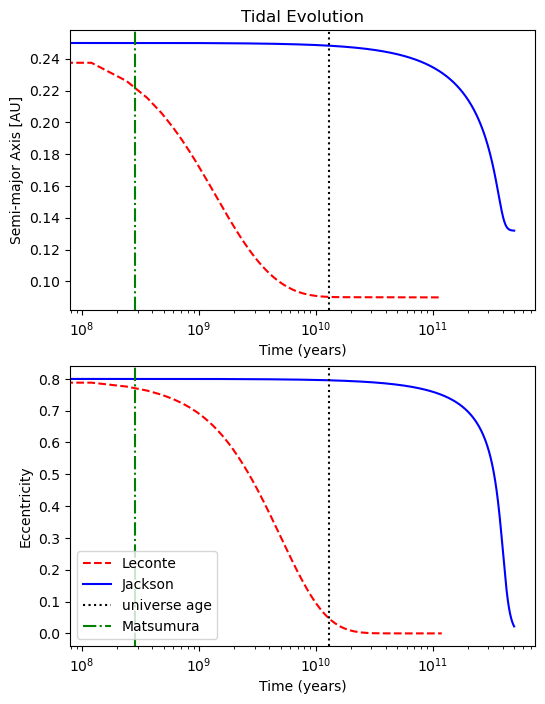

In [5]:
fig, ax = plt.subplots(2,1,figsize=(6, 8))
ax[0].plot(times_rescaled, planet_lec_a, color = "r", linestyle = "dashed", label = "Leconte")
ax[0].plot(jackson_times, a_sol, color = "b", label = "Jackson")
ax[0].axvline(x = 1.3e10, color = "k", linestyle = "dotted", label = "universe age")
ax[0].axvline(x = time, color = "g", linestyle = "dashdot", label = "Matsumura")
ax[0].set_ylabel('Semi-major Axis [AU]')
ax[0].set_xlabel('Time (years)')
ax[0].set_xscale("log")

ax[1].plot(times_rescaled, planet_lec_e, color = "r", linestyle = "dashed", label = "Leconte")
ax[1].plot(jackson_times, e_sol, color = "b", label = "Jackson")
ax[1].axvline(x = 1.3e10, color = "k", linestyle = "dotted", label = "universe age")
ax[1].axvline(x = time, color = "g", linestyle = "dashdot", label = "Matsumura")
ax[1].set_xscale("log")
ax[1].set_ylabel('Eccentricity')
ax[1].set_xlabel('Time (years)')
ax[1].legend(loc = "lower left")

ax[0].set_title("Tidal Evolution")